# Tesla Deliveries, Production & Pricing Analysis

## Project Overview
This project builds an end-to-end machine learning pipeline using Tesla deliveries and production data (2015–2025).

Objectives:
- Data preprocessing
- Exploratory Data Analysis (EDA)
- Feature engineering
- Regression modeling
- Hyperparameter tuning
- Time series forecasting


## Import Libraries

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split, GridSearchCV
from sklearn.linear_model import LinearRegression
from sklearn.ensemble import RandomForestRegressor
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score

plt.style.use('ggplot')


## Load Dataset

In [3]:
df = pd.read_csv('tesla_deliveries_dataset_2015_2025.csv')
df.head()

,Year,Month,Region,Model,Estimated_Deliveries,Production_Units,Avg_Price_USD,Battery_Capacity_kWh,Range_km,CO2_Saved_tons,Source_Type,Charging_Stations
0,2023,5,Europe,Model S,17646,17922,92874.27,120,704,1863.42,Interpolated (Month),12207
1,2015,2,Asia,Model X,3797,4164,62205.65,75,438,249.46,Official (Quarter),7640
2,2019,1,North America,Model X,8411,9189,117887.32,82,480,605.59,Interpolated (Month),14071
3,2021,2,North America,Model 3,6555,7311,89294.91,120,712,700.07,Official (Quarter),9333
4,2016,12,Middle East,Model Y,12374,13537,114846.78,120,661,1226.88,Estimated (Region),8722


## Data Preprocessing

In [4]:
df.info()
df.isnull().sum()
df.duplicated().sum()

df['Date'] = pd.to_datetime(df['Year'].astype(str)+'-'+df['Month'].astype(str)+'-01')


<class 'pandas.core.frame.DataFrame'>
RangeIndex: 2640 entries, 0 to 2639
Data columns (total 12 columns):
 #   Column                Non-Null Count  Dtype  
---  ------                --------------  -----  
 0   Year                  2640 non-null   int64  
 1   Month                 2640 non-null   int64  
 2   Region                2640 non-null   object 
 3   Model                 2640 non-null   object 
 4   Estimated_Deliveries  2640 non-null   int64  
 5   Production_Units      2640 non-null   int64  
 6   Avg_Price_USD         2640 non-null   float64
 7   Battery_Capacity_kWh  2640 non-null   int64  
 8   Range_km              2640 non-null   int64  
 9   CO2_Saved_tons        2640 non-null   float64
 10  Source_Type           2640 non-null   object 
 11  Charging_Stations     2640 non-null   int64  
dtypes: float64(2), int64(7), object(3)
memory usage: 247.6+ KB


## Exploratory Data Analysis

### 1. Monthly Deliveries Trend

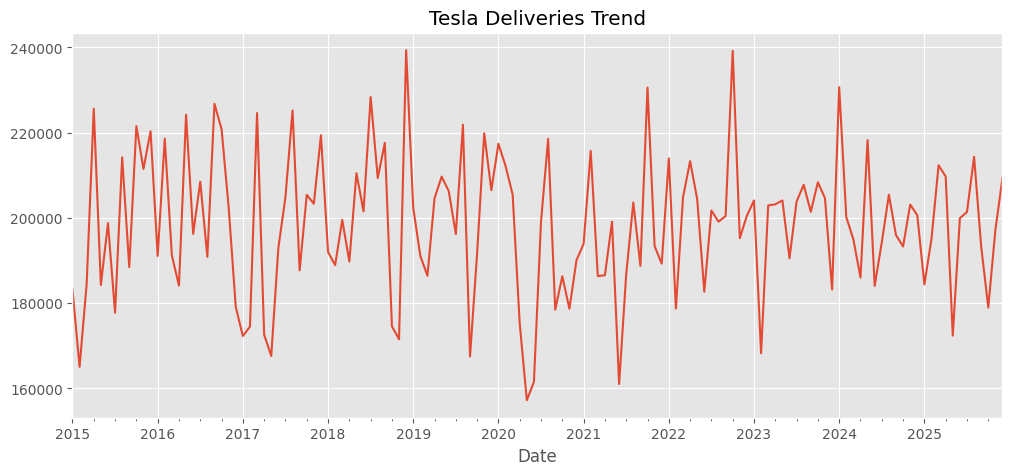

In [5]:
monthly=df.groupby('Date')['Estimated_Deliveries'].sum()

plt.figure(figsize=(12,5))
monthly.plot()
plt.title('Tesla Deliveries Trend')
plt.show()


### 2. Production Trend

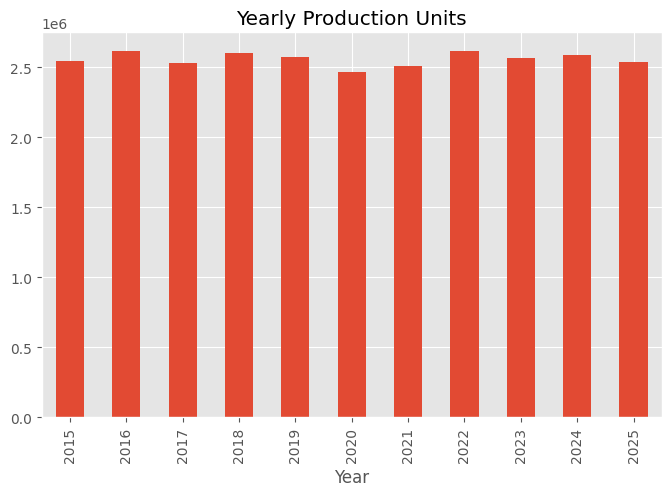

In [6]:
prod=df.groupby('Year')['Production_Units'].sum()

plt.figure(figsize=(8,5))
prod.plot(kind='bar')
plt.title('Yearly Production Units')
plt.show()


### 3. Region-wise Deliveries

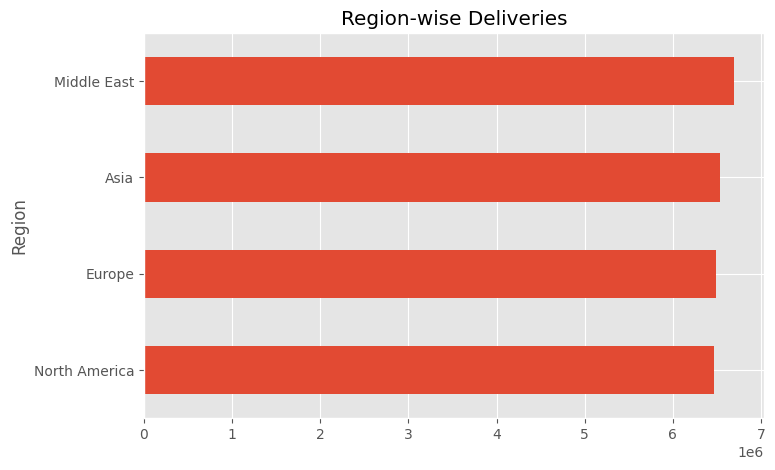

In [7]:
region=df.groupby('Region')['Estimated_Deliveries'].sum().sort_values()

plt.figure(figsize=(8,5))
region.plot(kind='barh')
plt.title('Region-wise Deliveries')
plt.show()


### 4. Top Tesla Models

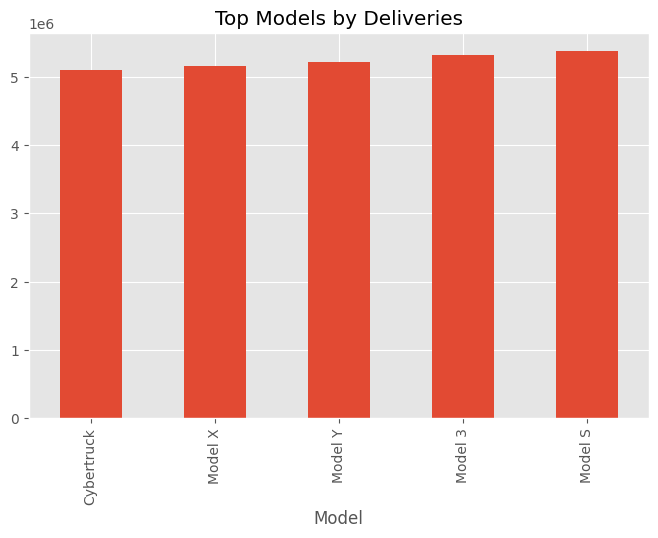

In [8]:
model=df.groupby('Model')['Estimated_Deliveries'].sum().sort_values()

plt.figure(figsize=(8,5))
model.tail(10).plot(kind='bar')
plt.title('Top Models by Deliveries')
plt.show()


### 5. Price Distribution

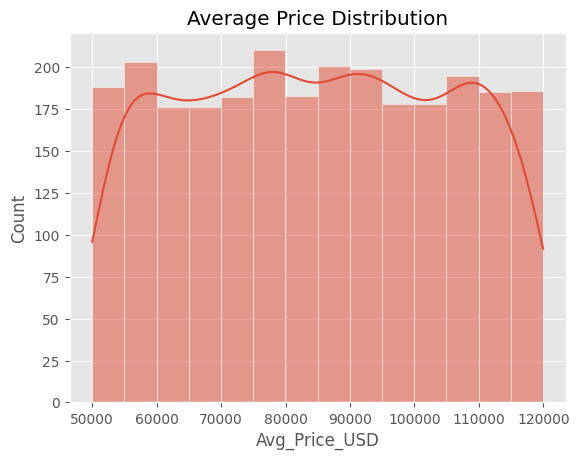

In [9]:
sns.histplot(df['Avg_Price_USD'],kde=True)
plt.title('Average Price Distribution')
plt.show()


### 6. Production vs Deliveries

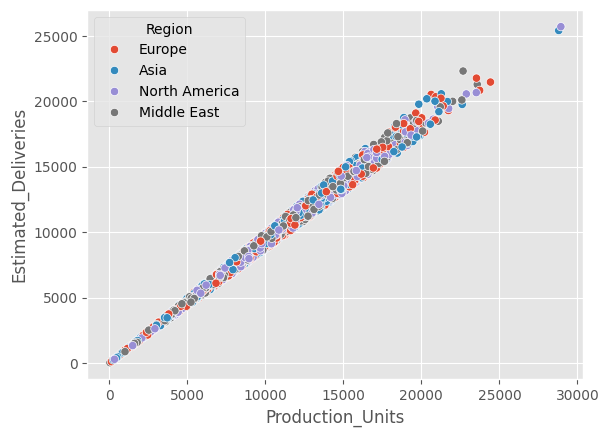

In [10]:
sns.scatterplot(data=df,
x='Production_Units',
y='Estimated_Deliveries',
hue='Region')

plt.show()


### 7. Correlation Heatmap

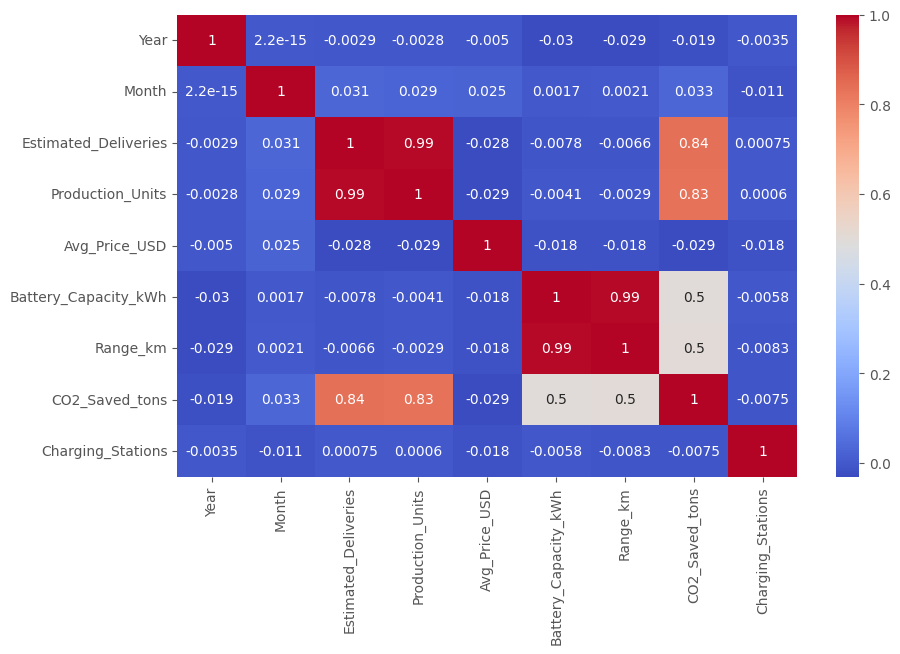

In [11]:
plt.figure(figsize=(10,6))
sns.heatmap(df.select_dtypes(include='number').corr(),
annot=True,cmap='coolwarm')
plt.show()


## Feature Engineering

In [12]:
df['Quarter']=df['Date'].dt.quarter

df['Delivery_Growth']=df['Estimated_Deliveries'].pct_change()

df['Production_Efficiency']=(
df['Estimated_Deliveries']/df['Production_Units']
)

df['Lag_Delivery']=df['Estimated_Deliveries'].shift(1)

df['Rolling_Delivery_Avg']=df['Estimated_Deliveries'].rolling(3).mean()

df=df.fillna(0)


## Regression Modeling

In [13]:
y=df['Estimated_Deliveries']

X=df.drop(['Estimated_Deliveries','Date'],axis=1)

X=pd.get_dummies(X,
columns=['Region','Model','Source_Type'],
drop_first=True)


In [14]:
X_train,X_test,y_train,y_test=train_test_split(
X,y,test_size=0.2,random_state=42)


### Linear Regression

In [15]:
lr=LinearRegression()
lr.fit(X_train,y_train)

pred_lr=lr.predict(X_test)

print("MAE:",mean_absolute_error(y_test,pred_lr))
print("RMSE:",np.sqrt(mean_squared_error(y_test,pred_lr)))
print("R2:",r2_score(y_test,pred_lr))


MAE: 108.8697231222434
RMSE: 153.80878096954282
R2: 0.9984129421831277


### Random Forest

In [16]:
rf=RandomForestRegressor(random_state=42)
rf.fit(X_train,y_train)

pred_rf=rf.predict(X_test)

print("MAE:",mean_absolute_error(y_test,pred_rf))
print("RMSE:",np.sqrt(mean_squared_error(y_test,pred_rf)))
print("R2:",r2_score(y_test,pred_rf))


MAE: 69.01138257575761
RMSE: 116.07736934009434
R2: 0.9990960891435915


## Hyperparameter Tuning

In [21]:
from sklearn.model_selection import GridSearchCV

params = {
    "n_estimators": [100, 200],
    "max_depth": [5, 10, 15]
}

grid = GridSearchCV(
    RandomForestRegressor(random_state=42),
    params,
    cv=5,
    scoring="r2"
)

grid.fit(X_train, y_train)

,estimator,RandomForestR...ndom_state=42)
,param_grid,"{'max_depth': [5, 10, ...], 'n_estimators': [100, 200]}"
,scoring,'r2'
,n_jobs,None
,refit,True
,cv,5
,verbose,0
,pre_dispatch,'2*n_jobs'
,error_score,nan
,return_train_score,False
,n_estimators,100


## Feature Importance

In [18]:
importance=pd.DataFrame({
'Feature':X.columns,
'Importance':grid.best_estimator_.feature_importances_
}).sort_values('Importance',ascending=False)

importance.head(10)


,Feature,Importance
2,Production_Units,0.990376
10,Production_Efficiency,0.008626
6,CO2_Saved_tons,0.000238
7,Charging_Stations,0.000103
3,Avg_Price_USD,0.000099
5,Range_km,0.000079
0,Year,0.000071
9,Delivery_Growth,0.000061
12,Rolling_Delivery_Avg,0.000055
1,Month,0.000052


## Time Series Forecasting

In [19]:
ts=df.groupby('Date')['Estimated_Deliveries'].sum().reset_index()

from prophet import Prophet

forecast_df=ts.rename(columns={
'Date':'ds',
'Estimated_Deliveries':'y'
})

model=Prophet()
model.fit(forecast_df)


23:25:21 - cmdstanpy - INFO - Chain [1] start processing
23:25:24 - cmdstanpy - INFO - Chain [1] done processing


D:\desktop-new\Lib\site-packages\prophet\forecaster.py:1875: FutureWarning: 'M' is deprecated and will be removed in a future version, please use 'ME' instead.
  dates = pd.date_range(


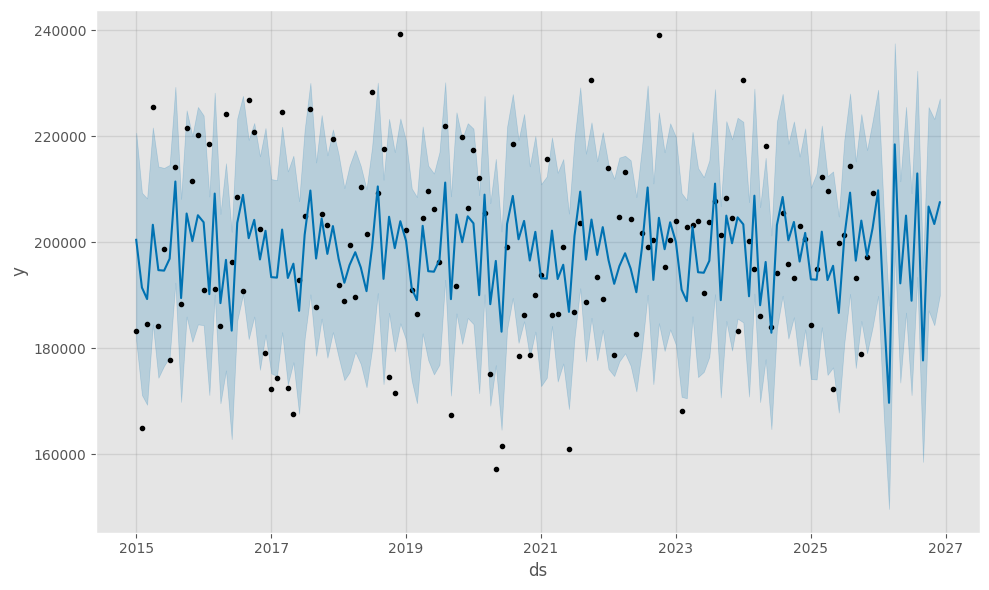

In [20]:
future=model.make_future_dataframe(periods=12,freq='M')
forecast=model.predict(future)

model.plot(forecast)
plt.show()


## Conclusion

Key Findings:

- Tesla deliveries showed consistent long-term growth.
- Production and deliveries are strongly related.
- Regional demand differs significantly.
- Random Forest generally performs better than Linear Regression.
- Forecasting indicates continued delivery growth in upcoming periods.

This notebook demonstrates a complete machine learning workflow from preprocessing to forecasting.
